--- AI BATCH DETECTION RESULTS ---

Photo 1 (data211213093_j...):
  -> 🎯 Detected: Class 3 with 91.5% confidence
  -> 🎯 Detected: Class 0 with 28.1% confidence
------------------------------
Photo 2 (cachua_967_jpg....):
  -> 🎯 Detected: Class 1 with 87.5% confidence
------------------------------
Photo 3 (Tot-188-_jpg.rf...):
  -> 🎯 Detected: Class 2 with 90.2% confidence
------------------------------


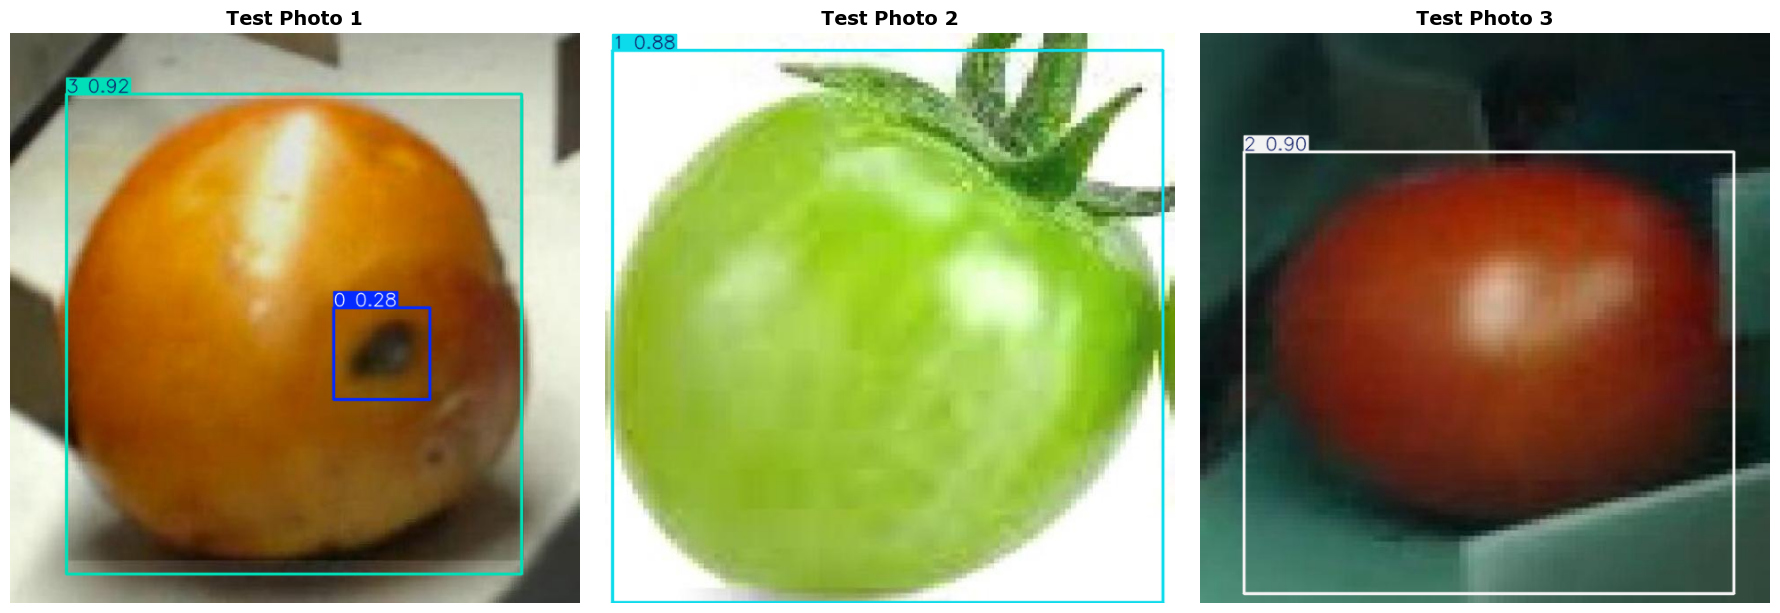

In [16]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load your custom trained model
model_path = r"C:\Users\hp zbook\Desktop\straiii\ai_model\runs\detect\sortx_v1\weights\best.pt"
model = YOLO(model_path)

# 2. Set up the folder path and the specific images you want to test
base_folder = r"C:\Users\hp zbook\Desktop\straiii\ai_model\tomato ripeness.v2i.yolov8\test\images"
image_names = [
    "data211213093_jpg.rf.7f9da49456ae0bcf58195add4c728aaf.jpg",
    "cachua_967_jpg.rf.baeab9fbbf93eb1f91e47d6bfc893694.jpg",
    "Tot-188-_jpg.rf.290f5500ad5da2a6aac733f45b07fd8b.jpg"
]
.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

print("--- AI BATCH DETECTION RESULTS ---\n")

# 4. Loop through each image, run the AI, and plot it
for i, img_name in enumerate(image_names):
    # Create the full path for the image
    full_path = os.path.join(base_folder, img_name)
    
    # Run the AI (verbose=False keeps the console output clean)
    results = model(full_path, save=False, verbose=False)
    
    # Print the text results to the console
    print(f"Photo {i+1} ({img_name[:15]}...):")
    if len(results[0].boxes) == 0:
        print("  -> No tomatoes detected!")
    else:
        for box in results[0].boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            print(f"  -> 🎯 Detected: Class {class_id} with {confidence*100:.1f}% confidence")
    print("-" * 30)

    # Convert the image colors and put it in the grid
    img_bgr = results[0].plot()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Display the image in its specific slot
    axes[i].imshow(img_rgb)
    axes[i].axis('off') # Hide the x/y coordinates
    axes[i].set_title(f"Test Photo {i+1}", fontsize=14, fontweight='bold')

# Show the final beautiful grid
plt.tight_layout()
plt.show()

### Class 0 = Defect / Damaged
### Class 1 = Unripe (Green)
### Class 2 = Ripe / Red
### Class 3 = Turning / Half-ripe (Orange/Yellow) (or possibly Overripe)